# NGC4698 electron-density maps from the [S II] doublet

**29 September 2026.** This notebook reads the two local primary-gas-fit
[S II] maps, computes the 6716/6731 ratio, converts that ratio to electron
density with PyNeb at an assumed electron temperature of 10,000 K, displays
the observed ratio, both density maps, and their quality categories, and writes a WCS-preserving FITS file.

The calculation is modeled on the density section of
/Users/Igniz/Desktop/ICRAR/further/SFR+Z.py. The two input files here
contain line values but no line-error maps or Balmer-line maps. Consequently
this is an **exploratory ratio-based map**, not the S/N-selected,
dust-corrected NE_SII product from that script. No density errors or
line-detection claims are made.

The additional NE_SII_ALL map assigns 20 cm^-3 where NE_SII is
unavailable inside the joint-finite input footprint. It is a filled
analysis map, not a second set of measured densities.

## 0. Inputs, output, and scientific choices

- Input 1: flux_map_SII6716_primary_gas_fit.fits
- Input 2: flux_map_SII6731_primary_gas_fit.fits
- Output: 20260929_NGC4698_NE_SII_Te10000K.fits, containing NE_SII and NE_SII_ALL
- Ratio: R = I([S II] 6716) / I([S II] 6731).
- Physics: PyNeb S II atom, current installed atomic files, assumed
  T_e = 10,000 K, and a 4,096-point grid spanning 20 to 100,000 cm^-3.

The ratio is dimensionless because both maps use the same recorded units.
Their BUNIT says per Angstrom, so the absolute flux threshold in SFR+Z.py
cannot be transferred safely to these two files. With no uncertainty maps,
the only default input selection is finite and positive values in *both*
lines. This is weaker than a detection/S/N selection.

A ratio above PyNeb's physical low-density limit at this temperature is
marked invalid. A ratio between that limit and the grid's 20 cm^-3 edge
is stored as a **20 cm^-3 floor**, not as a resolved measurement. A ratio
below the 100,000 cm^-3 grid edge is also invalid. SFR+Z.py clamps all
above-grid ratios to 20 cm^-3; this notebook excludes ratios above the
physical low-density limit to make the issue visible.

In [1]:
from pathlib import Path

import astropy
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap, LogNorm
from matplotlib.patches import Patch
import numpy as np
import pyneb as pn
from astropy.io import fits
from astropy.wcs import WCS

WORKDIR = Path("/Users/Igniz/Desktop/ICRAR/NGC4698")
SII6716_FILE = WORKDIR / "flux_map_SII6716_primary_gas_fit.fits"
SII6731_FILE = WORKDIR / "flux_map_SII6731_primary_gas_fit.fits"
LOOKUP_FILE = WORKDIR / (
    "pyneb_sii_6716_6731_density_lookup_"
    "te8000_13000_step1000_ne20_100000_n4096.npz"
)
OUTPUT_FILE = WORKDIR / "20260929_NGC4698_NE_SII_Te10000K.fits"

TE_K = 10_000.0
NE_MIN_CM3 = 20.0
NE_MAX_CM3 = 100_000.0
N_GRID = 4096
MIN_LINE_VALUE = 0.0  # Optional strength floor, not an S/N threshold.

for path in (SII6716_FILE, SII6731_FILE):
    if not path.is_file():
        raise FileNotFoundError(path)
print("Python dependencies:",
      "NumPy", np.__version__,
      "Astropy", astropy.__version__,
      "PyNeb", pn.__version__,
      "Matplotlib", matplotlib.__version__)
print("Inputs:", SII6716_FILE.name, "and", SII6731_FILE.name)
print("Output:", OUTPUT_FILE)

Python dependencies: NumPy 2.2.6 Astropy 7.0.2 PyNeb 1.1.30 Matplotlib 3.10.3
Inputs: flux_map_SII6716_primary_gas_fit.fits and flux_map_SII6731_primary_gas_fit.fits
Output: /Users/Igniz/Desktop/ICRAR/NGC4698/20260929_NGC4698_NE_SII_Te10000K.fits


## 1. Load the two maps and verify that their pixel grids match

FITS data are indexed as [y, x]. We copy both input headers, check their
shapes and celestial WCS at several pixels, and report their recorded units.
A pixel-by-pixel line ratio is meaningful only when both maps refer to the
same sky position at each array index.

In [2]:
with fits.open(SII6716_FILE, memmap=True) as hdul:
    flux_6716 = np.asarray(hdul[0].data, dtype=np.float64)
    header_6716 = hdul[0].header.copy()
with fits.open(SII6731_FILE, memmap=True) as hdul:
    flux_6731 = np.asarray(hdul[0].data, dtype=np.float64)
    header_6731 = hdul[0].header.copy()

if flux_6716.ndim != 2 or flux_6716.shape != flux_6731.shape:
    raise ValueError("Both [S II] inputs must be matching 2-D maps")
if header_6716.get("OBJECT", "").strip() != "NGC4698":
    raise ValueError("The 6716 input OBJECT is not NGC4698")
if header_6731.get("OBJECT", "").strip() != "NGC4698":
    raise ValueError("The 6731 input OBJECT is not NGC4698")
if header_6716.get("BUNIT") != header_6731.get("BUNIT"):
    raise ValueError("The two [S II] maps have different recorded units")

wcs_6716 = WCS(header_6716).celestial
wcs_6731 = WCS(header_6731).celestial
ny, nx = flux_6716.shape
probe_x = np.array([0, nx // 2, nx - 1], dtype=float)
probe_y = np.array([0, ny // 2, ny - 1], dtype=float)
sky_6716 = wcs_6716.pixel_to_world_values(probe_x, probe_y)
sky_6731 = wcs_6731.pixel_to_world_values(probe_x, probe_y)
if not all(np.allclose(a, b, rtol=0, atol=1e-8)
           for a, b in zip(sky_6716, sky_6731)):
    raise ValueError("The input celestial WCS grids differ")

print(f"Shape: {ny} rows x {nx} columns")
print("Input BUNIT:", header_6716["BUNIT"])
print("Finite, positive pixels:",
      np.count_nonzero(np.isfinite(flux_6716) & (flux_6716 > 0)),
      "at 6716 and",
      np.count_nonzero(np.isfinite(flux_6731) & (flux_6731 > 0)),
      "at 6731")

Shape: 1189 rows x 608 columns
Input BUNIT: 10**-20 Angstrom-1 cm-2 erg s-1
Finite, positive pixels: 353619 at 6716 and 353619 at 6731


## 2. Form the observed doublet ratio

Require finite positive values in both maps. MIN_LINE_VALUE can impose an
extra value cut, but it must not be described as S/N without matching error
maps. Missing, nonpositive, or excluded pixels remain NaN in the ratio map.
No reddening correction is possible from these two files alone.

In [3]:
usable = (
    np.isfinite(flux_6716) & np.isfinite(flux_6731)
    & (flux_6716 > MIN_LINE_VALUE)
    & (flux_6731 > MIN_LINE_VALUE)
)
ratio = np.full(flux_6716.shape, np.nan, dtype=np.float64)
np.divide(flux_6716, flux_6731, out=ratio, where=usable)
usable &= np.isfinite(ratio) & (ratio > 0)
ratio[~usable] = np.nan

print(f"Pixels with both usable lines: {np.count_nonzero(usable):,}")
print("Observed ratio percentiles (1, 50, 99):",
      np.nanpercentile(ratio, [1, 50, 99]))

Pixels with both usable lines: 353,619
Observed ratio percentiles (1, 50, 99): [0.93241462 1.48788823 1.97717043]


## 3. Display the observed [S II] ratio map

Plot the dimensionless 6716/6731 ratio **before** converting it to
electron density. Gray marks pixels without two finite positive line
values. The displayed colours span the 1st to 99th percentiles of valid
ratios; values outside that interval are clipped only in the figure,
not in the ratio array or FITS output. This is the uncorrected observed
ratio, with no S/N cut because line-error maps are unavailable.

Ratio display range (1st-99th percentile): 0.932 to 1.977


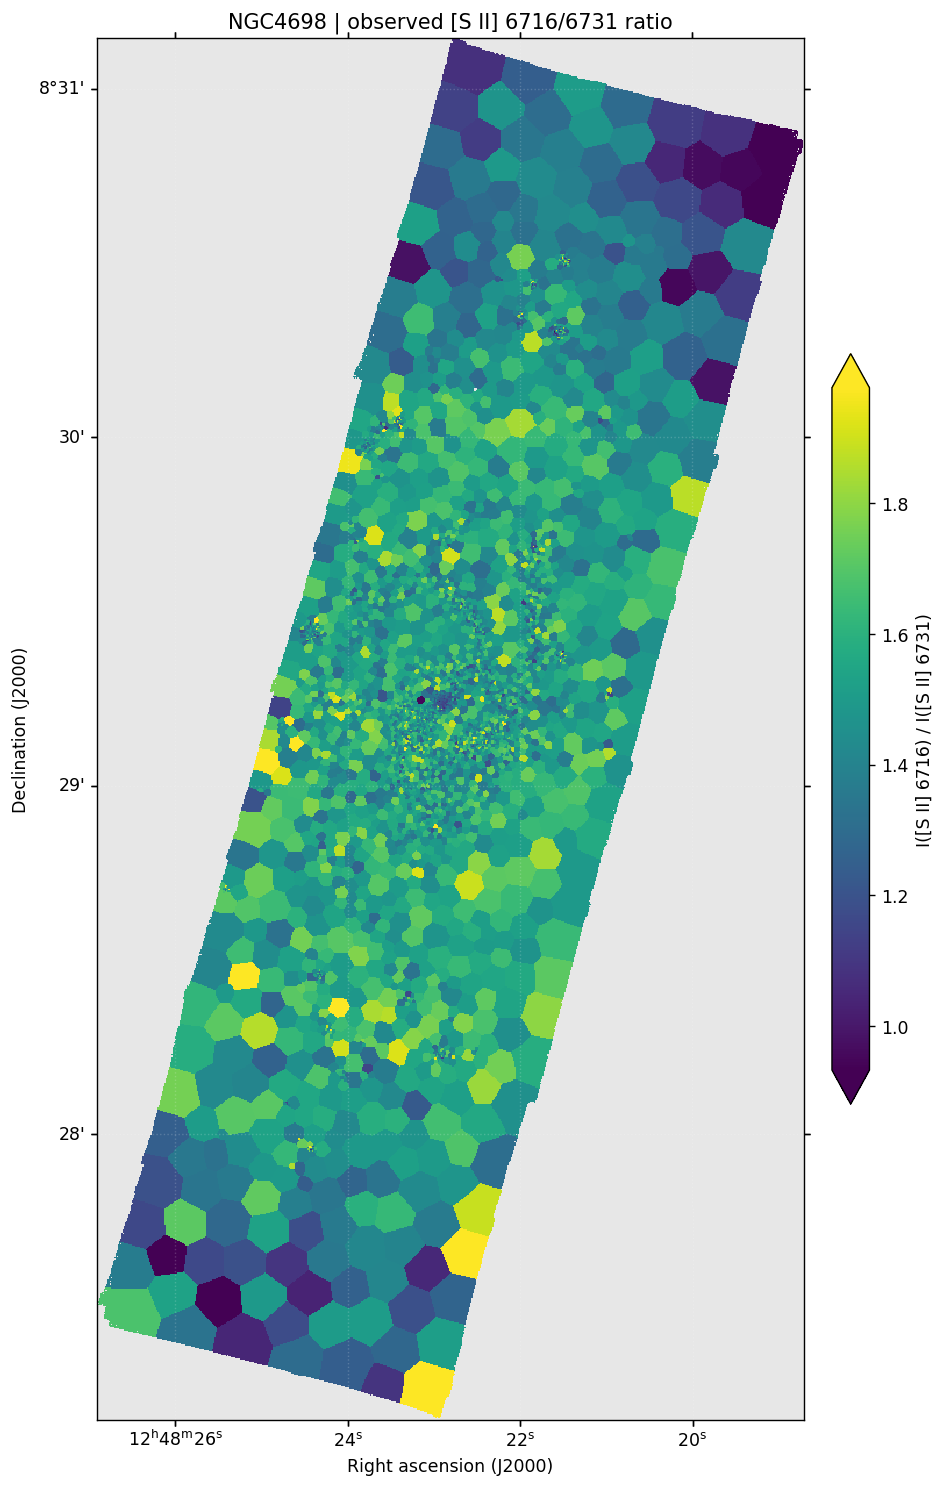

In [4]:
ratio_pixels = np.isfinite(ratio)
if not np.any(ratio_pixels):
    raise ValueError("No valid [S II] line ratios to display")
ratio_vmin, ratio_vmax = np.nanpercentile(ratio, [1, 99])
if not ratio_vmax > ratio_vmin:
    raise ValueError("The ratio display range is degenerate")
ratio_cmap = plt.get_cmap("viridis").copy()
ratio_cmap.set_bad("#e7e7e7")

fig = plt.figure(figsize=(9, 12))
ax = fig.add_subplot(111, projection=wcs_6716)
image = ax.imshow(
    np.ma.masked_invalid(ratio), origin="lower",
    cmap=ratio_cmap, vmin=ratio_vmin, vmax=ratio_vmax,
    interpolation="nearest",
)
ax.set_title("NGC4698 | observed [S II] 6716/6731 ratio")
ax.coords[0].set_axislabel("Right ascension (J2000)")
ax.coords[1].set_axislabel("Declination (J2000)")
ax.coords.grid(color="white", alpha=0.18, linestyle=":")
colorbar = fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03,
                        extend="both")
colorbar.set_label("I([S II] 6716) / I([S II] 6731)")
fig.tight_layout()
plt.show()
print(f"Ratio display range (1st-99th percentile): "
      f"{ratio_vmin:.3f} to {ratio_vmax:.3f}")

## 4. Build the PyNeb ratio-to-density relation

PyNeb calculates the [S II] emissivity of each line at the same temperature
and density. The emissivity ratio is a monotonic function of electron
density on this grid. This code rebuilds the relation directly from PyNeb,
so the notebook does not depend on the pre-existing NPZ cache. If that
cache is present, its 10,000 K row is compared as a provenance check.

The inferred density depends on the adopted temperature and PyNeb atomic
files. These are recorded in the FITS output. The diagnostic inversion is
supported by the [PyNeb documentation](https://morisset.github.io/PyNeb_devel/)
and its [Atom API](https://morisset.github.io/PyNeb_devel/api_reference/core/pynebcore/).

In [5]:
sii = pn.Atom("S", 2)
density_grid = np.geomspace(NE_MIN_CM3, NE_MAX_CM3, N_GRID)
emissivity_6716 = np.asarray(
    sii.getEmissivity(tem=TE_K, den=density_grid, wave=6716),
    dtype=float,
)
emissivity_6731 = np.asarray(
    sii.getEmissivity(tem=TE_K, den=density_grid, wave=6731),
    dtype=float,
)
theoretical_ratio = emissivity_6716 / emissivity_6731
if theoretical_ratio.shape != density_grid.shape:
    raise ValueError("Unexpected PyNeb emissivity-grid shape")
if not np.all(np.isfinite(theoretical_ratio)):
    raise ValueError("PyNeb ratio grid contains nonfinite values")
if not np.all(np.diff(theoretical_ratio) < 0):
    raise ValueError("The PyNeb density ratio is not strictly decreasing")

ratio_at_20 = float(theoretical_ratio[0])
ratio_at_100000 = float(theoretical_ratio[-1])
low_density_limit = float(sii.getLowDensRatio(
    wave1=6716, wave2=6731, tem=TE_K
))
if low_density_limit <= ratio_at_20:
    raise ValueError("The physical low-density limit is below the grid edge")

print("PyNeb S II atomic data:", sii.atomFile, "/", sii.collFile)
print(f"R(100,000 cm^-3) = {ratio_at_100000:.6f}")
print(f"R(20 cm^-3) = {ratio_at_20:.6f}")
print(f"Low-density ratio limit = {low_density_limit:.6f}")
if LOOKUP_FILE.is_file():
    with np.load(LOOKUP_FILE, allow_pickle=False) as cache:
        same_grid = np.allclose(cache["density_grid"], density_grid)
        same_temperature = np.isclose(float(cache["selected_tem"]), TE_K)
        cached_ratio = cache["selected_ratio_grid"]
        max_difference = float(np.max(np.abs(
            cached_ratio - theoretical_ratio
        ))) if cached_ratio.shape == theoretical_ratio.shape else np.inf
    print("Existing lookup check:",
          f"same density grid={same_grid},",
          f"same temperature={same_temperature},",
          f"max |Delta R|={max_difference:.3g}")

PyNeb S II atomic data: s_ii_atom_RGJ19.dat / s_ii_coll_TZ10.dat
R(100,000 cm^-3) = 0.447444
R(20 cm^-3) = 1.432332
Low-density ratio limit = 1.454944
Existing lookup check: same density grid=True, same temperature=True, max |Delta R|=1.67e-16


## 5. Invert the ratio and label quality categories

A measured density requires the ratio to lie within the computed 20 to
100,000 cm^-3 relation. Because theoretical ratio decreases with density,
reverse both arrays for NumPy interpolation. The grid-edge category between
R(20 cm^-3) and the physical low-density limit receives 20 cm^-3 as a floor;
it does **not** measure exactly 20 cm^-3. Ratios beyond the physical limit
and beyond the high-density grid remain NaN.

QC codes: 0 = unusable input; 1 = within the PyNeb density grid;
2 = below the 20 cm^-3 floor; 3 = ratio above physical low-density limit;
4 = ratio below the 100,000 cm^-3 grid edge.

In [6]:
qc = np.zeros(ratio.shape, dtype=np.uint8)
measured = usable & (ratio >= ratio_at_100000) & (ratio <= ratio_at_20)
floor_20 = usable & (ratio > ratio_at_20) & (ratio <= low_density_limit)
above_limit = usable & (ratio > low_density_limit)
beyond_high_density = usable & (ratio < ratio_at_100000)
qc[measured] = 1
qc[floor_20] = 2
qc[above_limit] = 3
qc[beyond_high_density] = 4

ne_map = np.full(ratio.shape, np.nan, dtype=np.float64)
ne_map[measured] = np.interp(
    ratio[measured], theoretical_ratio[::-1], density_grid[::-1]
)
ne_map[floor_20] = NE_MIN_CM3
if not np.all(np.isfinite(ne_map[measured])):
    raise ValueError("Interpolation failed on an in-grid ratio")
if not np.all(np.isnan(ne_map[above_limit | beyond_high_density])):
    raise ValueError("Out-of-range ratios were assigned a density")

labels = {
    0: "unusable input",
    1: "in-grid density",
    2: "20 cm^-3 floor",
    3: "above physical ratio limit",
    4: "below 100,000 cm^-3 ratio edge",
}
for code_value, label in labels.items():
    count = int(np.count_nonzero(qc == code_value))
    print(f"QC {code_value}: {label:34s} {count:>8,}")
print(f"Finite NE_SII pixels: {np.count_nonzero(np.isfinite(ne_map)):,}")
if np.any(measured):
    print("Median in-grid density:",
          f"{np.median(ne_map[measured]):.1f} cm^-3")

QC 0: unusable input                      369,293
QC 1: in-grid density                     138,292
QC 2: 20 cm^-3 floor                       15,625
QC 3: above physical ratio limit          199,702
QC 4: below 100,000 cm^-3 ratio edge            0
Finite NE_SII pixels: 153,917
Median in-grid density: 144.2 cm^-3


## 6. Display the electron-density map

The density colour scale is logarithmic. Light gray is NaN (no density
reported), while the darkest mapped value includes the 20 cm^-3 floor.
The following quality map distinguishes the floor from a resolved
in-grid value and shows where the observed ratio is physically out of
range at the assumed temperature.

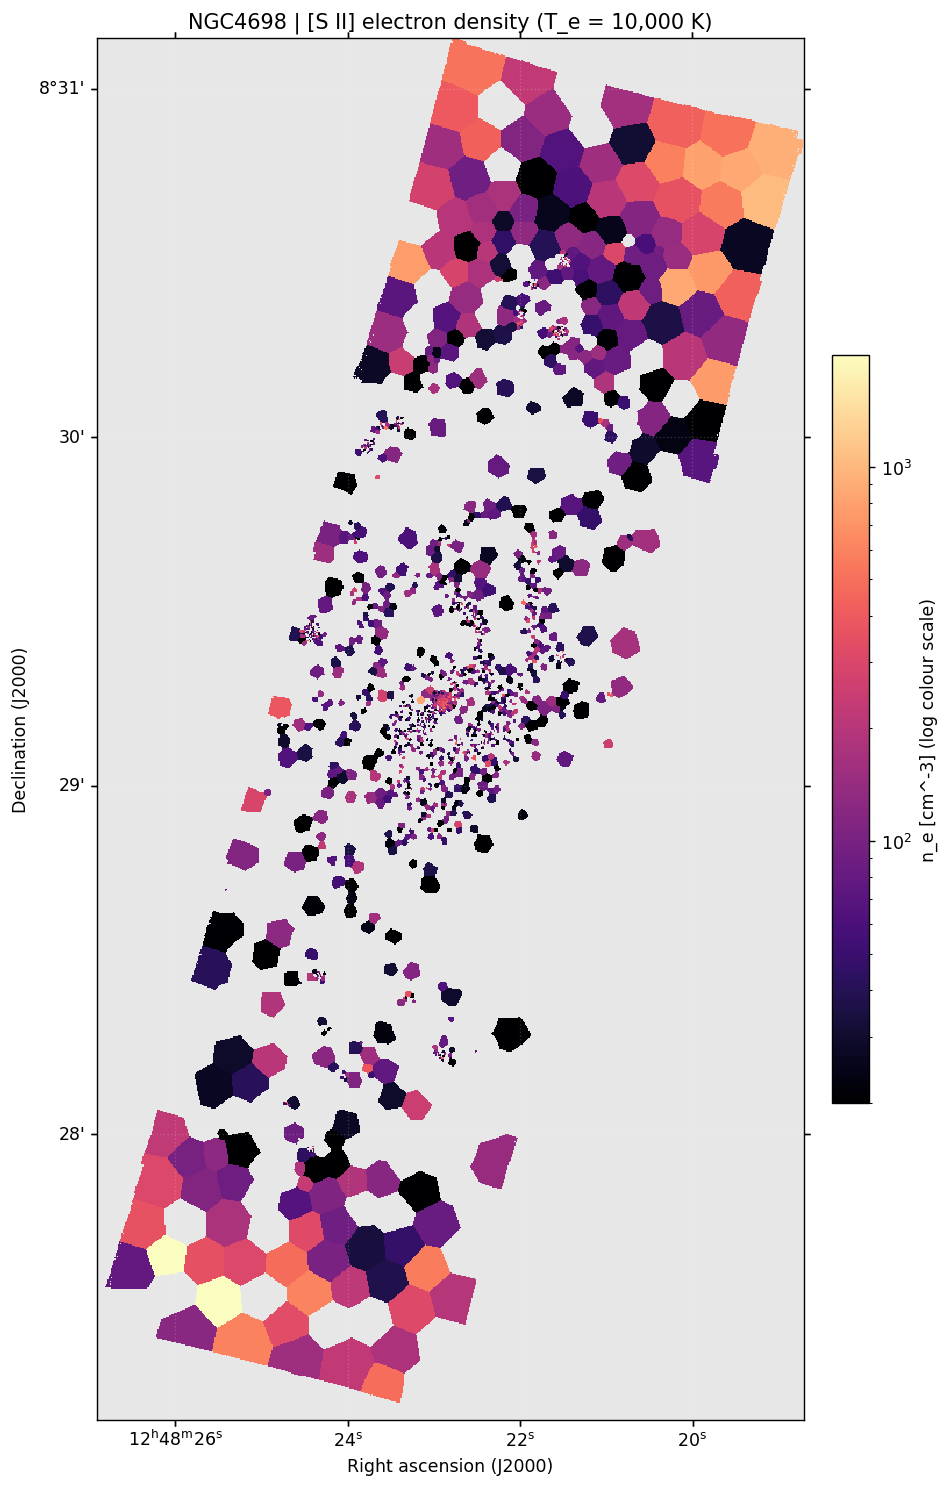

In [7]:
valid_ne = np.isfinite(ne_map)
if not np.any(valid_ne):
    raise ValueError("No finite electron densities to display")
vmax = max(1000.0, float(np.nanpercentile(ne_map[measured], 99)))
density_cmap = plt.get_cmap("magma").copy()
density_cmap.set_bad("#e7e7e7")

fig = plt.figure(figsize=(9, 12))
ax = fig.add_subplot(111, projection=wcs_6716)
image = ax.imshow(
    np.ma.masked_invalid(ne_map), origin="lower",
    cmap=density_cmap, norm=LogNorm(vmin=NE_MIN_CM3, vmax=vmax),
    interpolation="nearest",
)
ax.set_title("NGC4698 | [S II] electron density (T_e = 10,000 K)")
ax.coords[0].set_axislabel("Right ascension (J2000)")
ax.coords[1].set_axislabel("Declination (J2000)")
ax.coords.grid(color="white", alpha=0.18, linestyle=":")
colorbar = fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03)
colorbar.set_label("n_e [cm^-3] (log colour scale)")
fig.tight_layout()
plt.show()

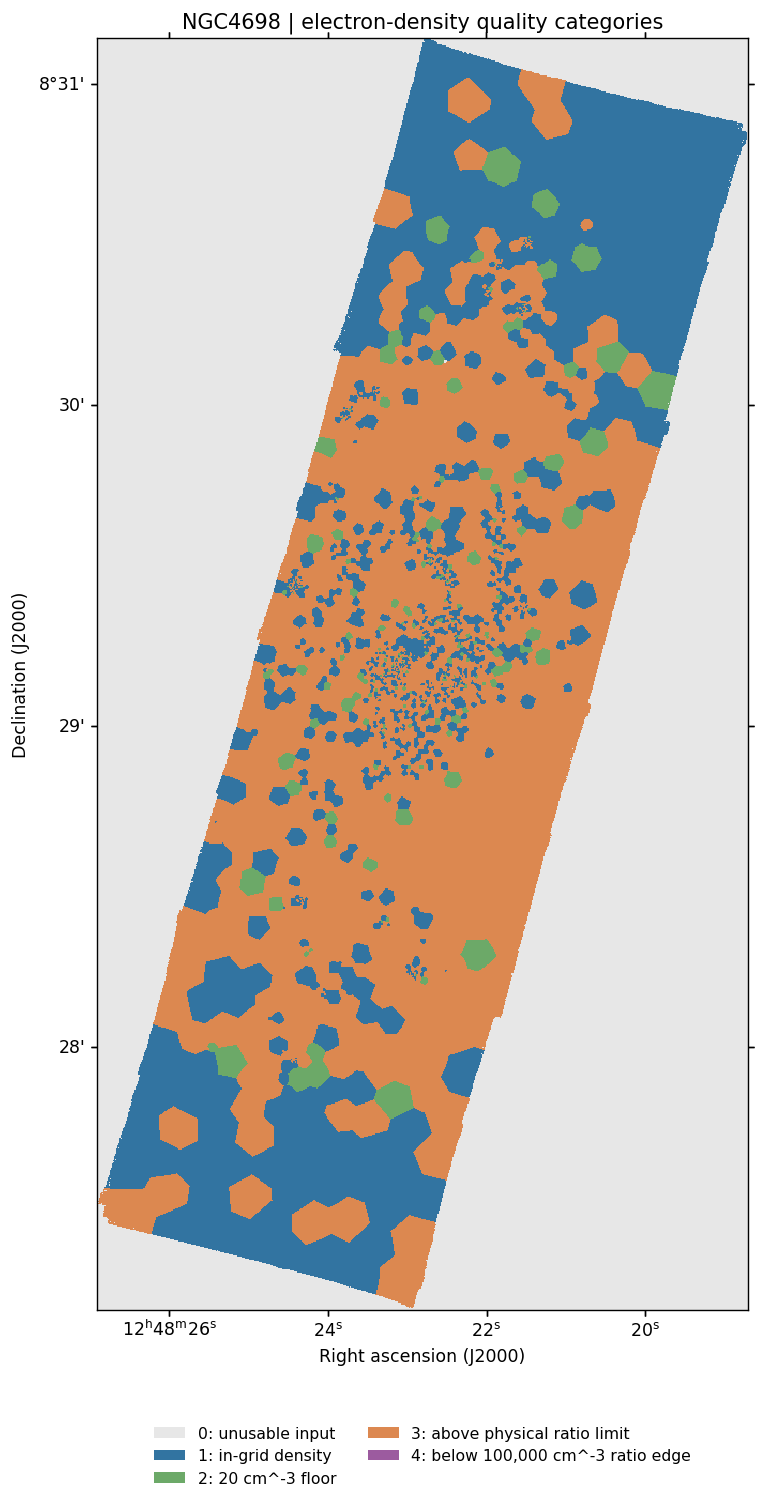

In [8]:
qc_colors = [
    "#e7e7e7",  # no usable input
    "#3274a1",  # in-grid measurement
    "#6ca968",  # 20 cm^-3 floor
    "#dc8850",  # above physical ratio limit
    "#9c5b9f",  # above high-density grid
]
qc_cmap = ListedColormap(qc_colors)
qc_norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), qc_cmap.N)
fig = plt.figure(figsize=(9, 12))
ax = fig.add_subplot(111, projection=wcs_6716)
ax.imshow(qc, origin="lower", cmap=qc_cmap, norm=qc_norm,
          interpolation="nearest")
ax.set_title("NGC4698 | electron-density quality categories")
ax.coords[0].set_axislabel("Right ascension (J2000)")
ax.coords[1].set_axislabel("Declination (J2000)")
handles = [Patch(facecolor=qc_colors[i], label=f"{i}: {labels[i]}")
           for i in range(5)]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.15),
          ncol=2, frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 7. Construct and display NE_SII_ALL

SFR+Z.py defines NE_SII_ALL by retaining finite NE_SII and assigning
20 cm^-3 to other spatially usable pixels. That script defines spatial
usability with its stellar-velocity map (V_STARS2). No such map is among
the inputs here, so this notebook uses pixels where **both [S II] input
maps are finite** as an explicit footprint proxy. This includes eight
zero-valued line pixels. Outside that footprint, NE_SII_ALL remains NaN.

Within the proxy footprint, existing NE_SII values are copied exactly.
Every other pixel is assigned 20 cm^-3, including ratios above the PyNeb
low-density limit. Such assigned values must not be read as measurements
or statistical upper limits. The ALL_FILL FITS extension marks them with
1. QC=2 still identifies the separate low-density floor from the original
NE_SII calculation. Compare this plot with the QC plot above.

Joint-finite input footprint: 353,627
Finite NE_SII retained: 153,917
New 20 cm^-3 fallback values: 199,710
NE_SII_ALL finite pixels: 353,627
NE_SII_ALL pixels displayed at 20 cm^-3: 215,335


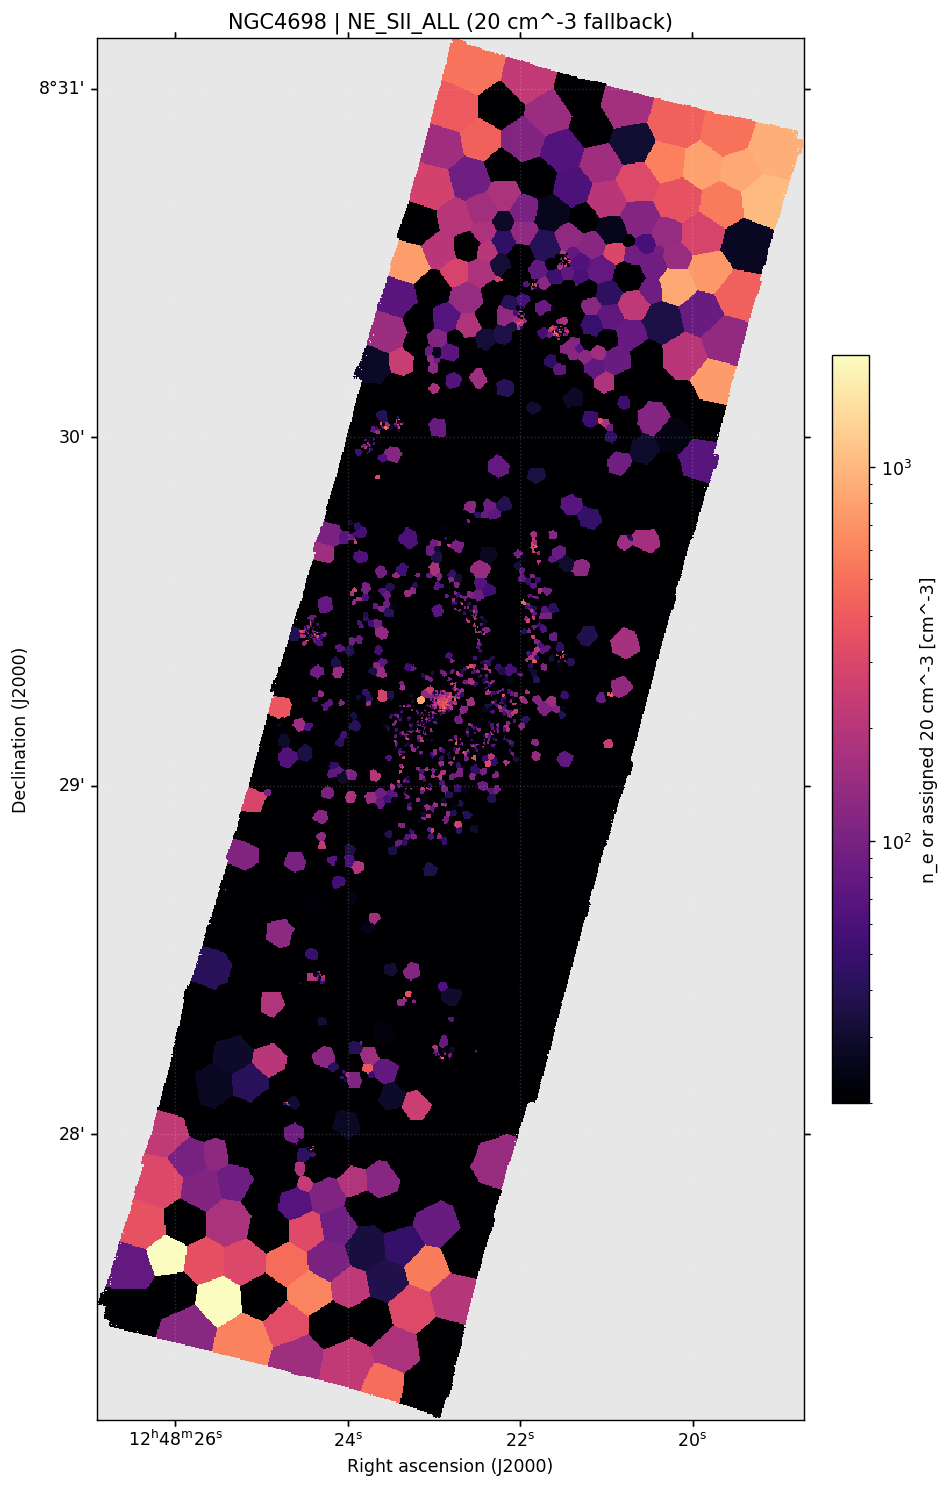

In [9]:
spatial_footprint = np.isfinite(flux_6716) & np.isfinite(flux_6731)
all_fill = spatial_footprint & ~np.isfinite(ne_map)
ne_all_map = np.where(
    spatial_footprint,
    np.where(np.isfinite(ne_map), ne_map, NE_MIN_CM3),
    np.nan,
)
if not np.array_equal(np.isfinite(ne_all_map), spatial_footprint):
    raise ValueError("NE_SII_ALL finite pixels do not match its footprint")
if not np.all(ne_all_map[all_fill] == NE_MIN_CM3):
    raise ValueError("NE_SII_ALL fill values are inconsistent")
if not np.allclose(
    ne_all_map[spatial_footprint & ~all_fill],
    ne_map[spatial_footprint & ~all_fill],
):
    raise ValueError("NE_SII_ALL changed a finite NE_SII value")

print(f"Joint-finite input footprint: {np.count_nonzero(spatial_footprint):,}")
print(f"Finite NE_SII retained: {np.count_nonzero(spatial_footprint & ~all_fill):,}")
print(f"New 20 cm^-3 fallback values: {np.count_nonzero(all_fill):,}")
print(f"NE_SII_ALL finite pixels: {np.count_nonzero(np.isfinite(ne_all_map)):,}")
print(f"NE_SII_ALL pixels displayed at 20 cm^-3: "
      f"{np.count_nonzero(ne_all_map == NE_MIN_CM3):,}")

fig = plt.figure(figsize=(9, 12))
ax = fig.add_subplot(111, projection=wcs_6716)
image = ax.imshow(
    np.ma.masked_invalid(ne_all_map), origin="lower",
    cmap=density_cmap, norm=LogNorm(vmin=NE_MIN_CM3, vmax=vmax),
    interpolation="nearest",
)
ax.set_title("NGC4698 | NE_SII_ALL (20 cm^-3 fallback)")
ax.coords[0].set_axislabel("Right ascension (J2000)")
ax.coords[1].set_axislabel("Declination (J2000)")
ax.coords.grid(color="white", alpha=0.18, linestyle=":")
colorbar = fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03)
colorbar.set_label("n_e or assigned 20 cm^-3 [cm^-3]")
fig.tight_layout()
plt.show()

## 8. Write and verify the FITS product

The primary HDU is NE_SII in cm^-3. NE_SII_ALL, SII_RATIO, QC, and ALL_FILL are companion HDUs.
Each HDU retains the two-dimensional celestial WCS. ALL_FILL is 1 where the 20 cm^-3 fallback was assigned and 0 elsewhere. The primary header
records the assumed temperature, density range, input names, PyNeb version,
and atomic files. On rerun, this notebook replaces *its own* named output.
The final code cell reopens the file and checks the stored arrays and WCS.

In [10]:
output_header = header_6716.copy()
output_header["WCSAXES"] = (2, "Two-dimensional celestial WCS")
output_header["BUNIT"] = ("cm-3", "Electron density")
output_header["EXTNAME"] = ("NE_SII", "Primary data name")
output_header["OBJECT"] = ("NGC4698", "Target galaxy")
output_header["TEASSUM"] = (TE_K, "Assumed electron temperature [K]")
output_header["NEMIN"] = (NE_MIN_CM3, "Minimum lookup density [cm-3]")
output_header["NEMAX"] = (NE_MAX_CM3, "Maximum lookup density [cm-3]")
output_header["NGRID"] = (N_GRID, "Number of lookup density points")
output_header["FLRATIO"] = (low_density_limit, "PyNeb low-density ratio limit")
output_header["PYNEBVER"] = (pn.__version__, "PyNeb version")
output_header["ATOMFILE"] = (sii.atomFile, "PyNeb S II transition data")
output_header["COLLFILE"] = (sii.collFile, "PyNeb S II collision data")
output_header["SII6716"] = (SII6716_FILE.name, "Numerator input")
output_header["SII6731"] = (SII6731_FILE.name, "Denominator input")
output_header["NOVAR"] = (True, "No input line-error maps available")
output_header.add_history(
    "Exploratory uncorrected [S II] 6716/6731 density; no S/N cut."
)
output_header.add_history(
    "Ratios above physical low-density limit or outside high-density "
    "grid are NaN."
)
output_header.add_history(
    "Values at 20 cm-3 are a floor; inspect QC extension before use."
)
output_header.add_history(
    "NE_SII_ALL uses both-input-finite footprint and 20 cm-3 fallback."
)

all_header = wcs_6716.to_header()
all_header["BUNIT"] = ("cm-3", "Density or assigned 20 cm-3")
all_header["TEASSUM"] = (TE_K, "Assumed electron temperature [K]")
all_header["FOOTPRNT"] = ("BOTH_FIN", "Both input maps finite")
all_header.add_history(
    "Finite NE_SII retained; otherwise 20 cm-3 within joint-finite footprint."
)
fill_header = wcs_6716.to_header()
fill_header["BUNIT"] = ("flag", "1 means NE_SII_ALL was filled")
fill_header["FILL0"] = ("not filled", "Includes outside-footprint pixels")
fill_header["FILL1"] = ("20 cm-3 assigned", "No finite NE_SII value")

ratio_header = wcs_6716.to_header()
ratio_header["BUNIT"] = ("1", "Dimensionless line ratio")
ratio_header["TEASSUM"] = (TE_K, "Assumed electron temperature [K]")
qc_header = wcs_6716.to_header()
qc_header["BUNIT"] = ("code", "Quality category")
for code_value, label in labels.items():
    qc_header[f"QC{code_value}"] = (label, "Quality-code meaning")

hdul_out = fits.HDUList([
    fits.PrimaryHDU(data=ne_map.astype(np.float32), header=output_header),
    fits.ImageHDU(data=ne_all_map.astype(np.float32),
                  header=all_header, name="NE_SII_ALL"),
    fits.ImageHDU(data=ratio.astype(np.float32),
                  header=ratio_header, name="SII_RATIO"),
    fits.ImageHDU(data=qc.astype(np.uint8),
                  header=qc_header, name="QC"),
    fits.ImageHDU(data=all_fill.astype(np.uint8),
                  header=fill_header, name="ALL_FILL"),
])
hdul_out.writeto(OUTPUT_FILE, overwrite=True, checksum=True)

with fits.open(OUTPUT_FILE, checksum=True) as saved:
    assert saved[0].header["BUNIT"] == "cm-3"
    assert np.allclose(saved[0].data, ne_map, rtol=1e-6,
                       atol=1e-6, equal_nan=True)
    assert np.array_equal(saved["QC"].data, qc)
    assert np.allclose(saved["NE_SII_ALL"].data, ne_all_map,
                       rtol=1e-6, atol=1e-6, equal_nan=True)
    assert np.array_equal(saved["ALL_FILL"].data, all_fill.astype(np.uint8))
    saved_wcs = WCS(saved[0].header).celestial
    all_wcs = WCS(saved["NE_SII_ALL"].header).celestial
    saved_sky = saved_wcs.pixel_to_world_values(probe_x, probe_y)
    all_sky = all_wcs.pixel_to_world_values(probe_x, probe_y)
    assert all(np.allclose(a, b, rtol=0, atol=1e-8)
               for a, b in zip(sky_6716, saved_sky))
    assert all(np.allclose(a, b, rtol=0, atol=1e-8)
               for a, b in zip(sky_6716, all_sky))
    saved.info()
print(f"Verified FITS output: {OUTPUT_FILE}")

Filename: /Users/Igniz/Desktop/ICRAR/NGC4698/20260929_NGC4698_NE_SII_Te10000K.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  NE_SII        1 PrimaryHDU      47   (608, 1189)   float32   
  1  NE_SII_ALL    1 ImageHDU        34   (608, 1189)   float32   
  2  SII_RATIO     1 ImageHDU        32   (608, 1189)   float32   
  3  QC            1 ImageHDU        36   (608, 1189)   uint8   
  4  ALL_FILL      1 ImageHDU        33   (608, 1189)   uint8   
Verified FITS output: /Users/Igniz/Desktop/ICRAR/NGC4698/20260929_NGC4698_NE_SII_Te10000K.fits


## Detailed calculation report for this NGC4698 run

The numbers below come from the executed notebook and FITS product dated
2026-09-29, with MIN_LINE_VALUE = 0.0. They describe *pixels in these two
maps*, not independent measurements of a galaxy population. If the inputs,
temperature, or selection setting change, rerun the notebook and update
this report.

### Inventory before the density calculation

| Item | Available here | Role in the calculation |
|---|---|---|
| [S II] 6716 input | flux_map_SII6716_primary_gas_fit.fits; 1,189 rows x 608 columns | Numerator of the doublet ratio |
| [S II] 6731 input | flux_map_SII6731_primary_gas_fit.fits; same shape and celestial WCS | Denominator of the doublet ratio |
| Recorded input unit | Both headers say 10**-20 Angstrom-1 cm-2 erg s-1 | Same units cancel in the ratio; the header does not by itself establish the integrated-flux scale used for an absolute flux cut |
| Pre-existing PyNeb lookup | 20 to 100,000 cm^-3 and 8,000 to 13,000 K | Cross-check only; this notebook rebuilds the 10,000 K row directly |
| Spatial-footprint proxy | Both [S II] maps finite at 353,627 pixels; the stellar-velocity map used by SFR+Z.py is unavailable here | Defines where a fallback value may be assigned in NE_SII_ALL |
| Missing inputs | No line-error or Balmer maps in this directory | No S/N selection, reddening correction, or density uncertainty can be calculated |
| Working assumptions | PyNeb 1.1.30; S II atomic files s_ii_atom_RGJ19.dat and s_ii_coll_TZ10.dat; $T_e=10,000$ K | Converts a line ratio into the electron density of the S+ emitting gas |

There are $1,189 \times 608 = 722,912$ image pixels. Each input has
369,285 NaNs, 8 zeros, and 353,619 finite positive values; the unusable
locations coincide. The input celestial WCS agrees at tested pixels, so
corresponding array entries refer to the same sky position.

### 1. Select the two line values and calculate their ratio

For pixel $(y,x)$, write the input values as $F_{6716}(y,x)$ and
$F_{6731}(y,x)$. A pixel is usable only if **both** are finite and greater
than MIN_LINE_VALUE = 0.0. Thus
$722,912 - 369,293 = 353,619$ pixels have an observed positive pair.
For each such pixel the notebook calculates

$$R(y,x)=F_{6716}(y,x)/F_{6731}(y,x).$$

The common recorded unit cancels, leaving a dimensionless ratio. Outside
the usable mask, $R$ is NaN. The observed ratio has 1st, 50th, and 99th
percentiles of 0.932415, 1.487888, and 1.977170. The median already
exceeds the theoretical low-density limit calculated below; it is
therefore essential to classify ratios before assigning densities.

### 2. Construct the [S II] theoretical relation

The notebook creates a PyNeb S II atom and a logarithmically spaced
density grid of 4,096 values from 20 to 100,000 cm$^{-3}$ at the assumed
$T_e=10,000$ K. At each grid value $n_i$, PyNeb computes the emissivities
of the two lines and their ratio:

$$R_i=j_{6716}(T_e,n_i)/j_{6731}(T_e,n_i).$$

For the installed atomic data, this relation decreases monotonically
with density. Its endpoints are $R(20)=1.432332$ and
$R(100,000)=0.447444$. PyNeb's low-density asymptotic ratio at this
temperature is 1.454944. The rebuilt 10,000 K curve matches the local
cached curve to a maximum absolute ratio difference of
$1.67 \times 10^{-16}$; the cached file is not needed to produce the map.

### 3. Convert a ratio into a density

If $0.447444 \leq R \leq 1.432332$, the ratio lies on the modeled grid.
The code reverses the decreasing ratio array and uses linear interpolation
in density. For neighboring grid ratios $R_i \geq R \geq R_{i+1}$,

$$f=(R_i-R)/(R_i-R_{i+1}); \qquad n_e=n_i+f(n_{i+1}-n_i).$$

As a concrete example, zero-based pixel $(x,y)=(296,617)$ has
$F_{6716}=9,459.06836$ and $F_{6731}=7,981.13721$ in the input maps.
Their ratio is $R=1.18517802$. It falls between
$(R_i,n_i)=(1.18530760,317.32302)$ and
$(R_{i+1},n_{i+1})=(1.18489528,317.98371)$, where density is in
cm$^{-3}$. The interpolation fraction is $f=0.314276$, giving
$n_e=317.53$ cm$^{-3}$ in the saved map.

Two boundaries need different treatment. If
$1.432332 < R \leq 1.454944$, the ratio is in the low-density regime
below this grid's 20 cm$^{-3}$ edge. The displayed value is set to
20 cm$^{-3}$ and QC=2 marks it as a **floor convention**, not a precise
measurement of 20. If $R>1.454944$, it exceeds the PyNeb low-density
ratio limit for the adopted temperature and atomic data: density is NaN
and QC=3. If $R<0.447444$, it lies beyond the 100,000 cm$^{-3}$ grid:
density is NaN and QC=4. No pixels fall in that last category here.

### 4. Account for every pixel

| QC | Meaning | Pixels | Share of all 722,912 | Share of 353,619 positive pairs |
|---:|---|---:|---:|---:|
| 0 | Missing, zero, or otherwise unusable input | 369,293 | 51.08% | -- |
| 1 | Ratio within the modeled density grid | 138,292 | 19.13% | 39.11% |
| 2 | Low-density regime assigned the 20 cm$^{-3}$ floor | 15,625 | 2.16% | 4.42% |
| 3 | Ratio above the modeled low-density limit; density NaN | 199,702 | 27.62% | 56.47% |
| 4 | Ratio beyond the high-density grid; density NaN | 0 | 0.00% | 0.00% |

The rows total 722,912 pixels. The density map has
$138,292+15,625=153,917$ finite values: 21.29% of all pixels or
43.53% of the positive input pairs. The remaining
$353,619-153,917=199,702$ positive pairs are above the modeled
low-density ratio limit. Of the finite density values, 15,625 (10.15%)
are the 20 cm$^{-3}$ floor category. Among **in-grid pixels only**, the
16th percentile, median, and 84th percentile are 42.4, 144.2, and
433.1 cm$^{-3}$. These are descriptive pixel summaries, not uncertainty
bounds or evidence of a spatial trend.

### 5. Construct NE_SII_ALL and identify its fallback values

In SFR+Z.py, NE_SII_ALL keeps finite NE_SII values and supplies
20 cm$^{-3}$ at other spatially usable positions. Its spatial mask is
based on finite V_STARS2, which these local inputs do not provide.
The notebook therefore uses the joint-finite [S II] footprint as an
explicit **proxy**, not an exact reproduction of that script's mask:

$$n_{e,\mathrm{all}}(y,x)=
\begin{cases}
n_{e,\mathrm{SII}}(y,x), & \text{if the [S II] density is finite},\\
20\ \mathrm{cm}^{-3}, & \text{if both line maps are finite but the density is NaN},\\
\mathrm{NaN}, & \text{otherwise}.
\end{cases}$$

The proxy footprint has 353,627 pixels: the 353,619 positive pairs
plus 8 positions where both input values are zero. Of these,
153,917 retain their NE_SII density and
$353,627-153,917=199,710$ receive the new 20 cm$^{-3}$ fallback.
The newly filled pixels consist of 199,702 above-limit ratio pixels
plus the 8 zero-valued input pixels. Hence NE_SII_ALL is finite in
353,627 pixels, and 215,335 display as 20 cm$^{-3}$: 15,625
low-density floor pixels already present in NE_SII plus 199,710
newly filled pixels. ALL_FILL=1 identifies the newly filled group;
QC=2 identifies the separate floor group. Neither group is a
precise density measurement.

### 6. What the files and figures contain

The first displayed figure is the uncorrected [S II] ratio map; its
colour display is clipped at the observed 1st and 99th percentiles.
The second figure shows NE_SII on a logarithmic colour scale, with
gray for NaN. The third maps the QC categories, and the fourth shows
NE_SII_ALL on the same density colour scale. The saved FITS file has primary HDU
NE_SII, plus NE_SII_ALL, SII_RATIO, QC, and ALL_FILL extensions. The
density HDUs use cm$^{-3}$; SII_RATIO is dimensionless. The primary
header records the temperature, grid bounds, PyNeb version and atomic
files, input filenames, and celestial WCS. The notebook reopens the FITS
file and checks the arrays and WCS after writing it.

### Interpretation and work still needed

NE_SII_ALL supplies a uniform fallback density inside a proxy footprint;
it cannot turn an unmeasured or out-of-range ratio into a measured
density. In this run, most of its 20 cm$^{-3}$ pixels are new fallback
values. Always use ALL_FILL and QC when analyzing that map.

This is an exploratory density diagnostic for the S+ emitting gas at an
*assumed* temperature. It is not a temperature map or a density map of
every ionized component. The 199,702 above-limit ratios signal that much
of the positive-pair footprint cannot be assigned a density with the
adopted model. Noise, line fitting, and calibration are possible
contributors, but these two maps alone cannot establish the cause.

SFR+Z.py uses detected lines, corrected fluxes, and error maps that are
unavailable here. It also handles the low-density boundary differently.
For a science-grade analysis, obtain aligned [S II] error maps, apply a
justified S/N and line-value selection, use Balmer data if matching its
reddening correction, propagate the ratio uncertainty through PyNeb, and
state any H II or other excitation mask. Recompute this report after
those choices; do not interpret the present floor pixels as exact
densities or infer physical gradients from the displayed patches.